# 降采样

文件内容：
dict_keys(['__header__', '__version__', '__globals__', 'x', 'y', 'data'])
数据形状: (7001, 7001)


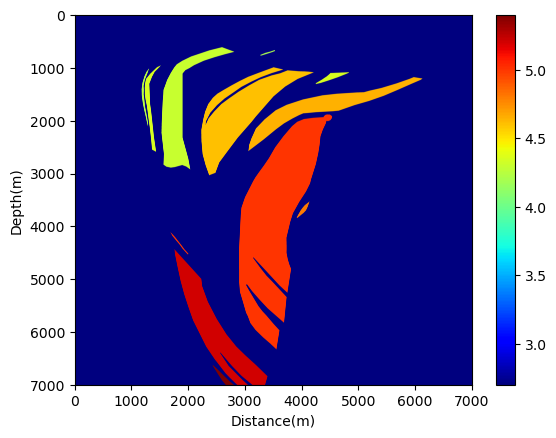

降采样后数据形状: (126, 126)


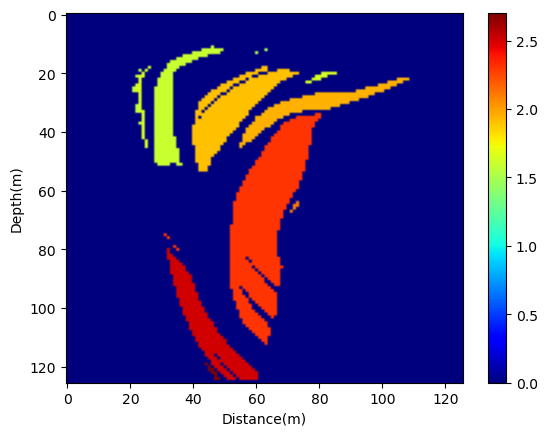

In [4]:
import numpy as np
from scipy import io
from matplotlib import pyplot as plt

def density_show(density:np.ndarray):
    plt.imshow(density, cmap="jet",aspect= 'auto')
    plt.colorbar()
    plt.xlabel('Distance(m)')
    plt.ylabel('Depth(m)')
    plt.show()

huoqiu_density = io.loadmat('../data/huoqiu_density.mat')
print("文件内容：")
print(huoqiu_density.keys())
data = huoqiu_density['data']
print(f"数据形状: {data.shape}")
density_show(data)

downsampled_data = data[::56, ::56]
backround_value = downsampled_data[0,0]
downsampled_data = downsampled_data - backround_value

print(f"降采样后数据形状: {downsampled_data.shape}")
density_show(downsampled_data)
np.savez('density_huoqiu.npz', density=downsampled_data)

# 生成重力数据

见`E:\Research\huoqiu\2D_gravity_calculation\main_huoqiu_unet_test_20260608.py`

# 模型测试

```
python infer.py `
--checkpoint checkpoints\geo_model\best_model.pth, checkpoints\geo_model\last_model.pth `
--input E:\Research\benchmark\2D_benchmark\huoqiu_unet_test\gravity_huoqiu\config1\model\gravity_huoqiu.npz `
--target_nx 126 `
--input_key gravity `
--save_dir E:\Research\benchmark\2D_benchmark\huoqiu_unet_test`
--sub_folder huoqiu\best_model, huoqiu\last_model `
--save_format npz `
```

## 绘制对比图

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

def plot_test_result(label, pred, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    density_img = axes[0].imshow(label, cmap="viridis", aspect='auto', vmin=0, vmax=1)
    axes[0].set_title("True Density Model", fontsize=12)
    axes[0].set_xlabel("X (Grid Points)")
    axes[0].set_ylabel("Z (Grid Points)")
    plt.colorbar(density_img, ax=axes[0])

    density_img = axes[1].imshow(pred, cmap="viridis", aspect='auto', vmin=0, vmax=1)
    axes[1].set_title("Pred Density Model", fontsize=12)
    axes[1].set_xlabel("X (Grid Points)")
    axes[1].set_ylabel("Z (Grid Points)")
    plt.colorbar(density_img, ax=axes[1])

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
    else:
        plt.show()
    
    plt.close()
    plt.clf()

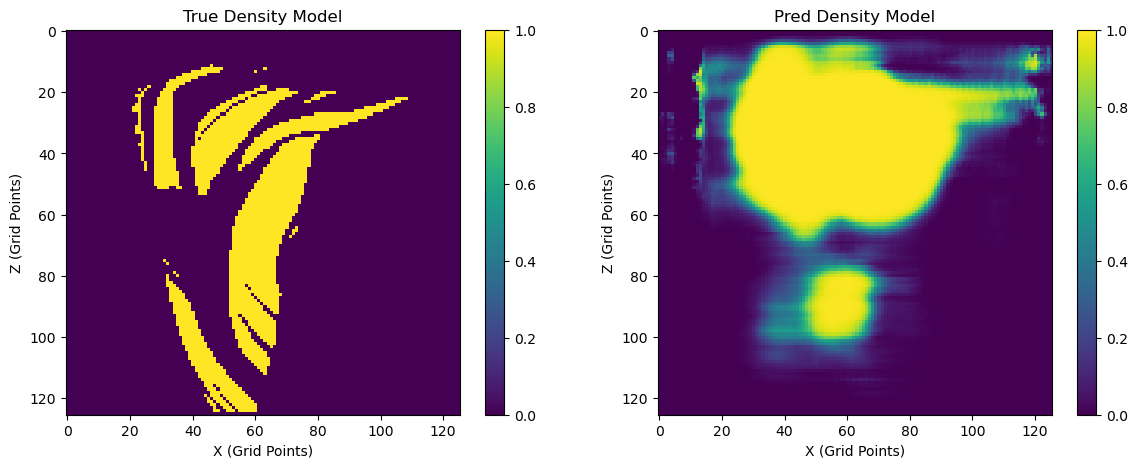

<Figure size 640x480 with 0 Axes>

In [2]:
label_path = r"E:\Research\benchmark\2D_benchmark\huoqiu_unet_test\density_huoqiu.npz"
label = np.load(label_path)['density']

model_type = "best_model"
pred_path = fr"E:\Research\benchmark\2D_benchmark\huoqiu_unet_test\v001\{model_type}\gravity_huoqiu_pred.npz"
pred = np.load(pred_path)['pred']

plot_test_result(label, pred[0,0])

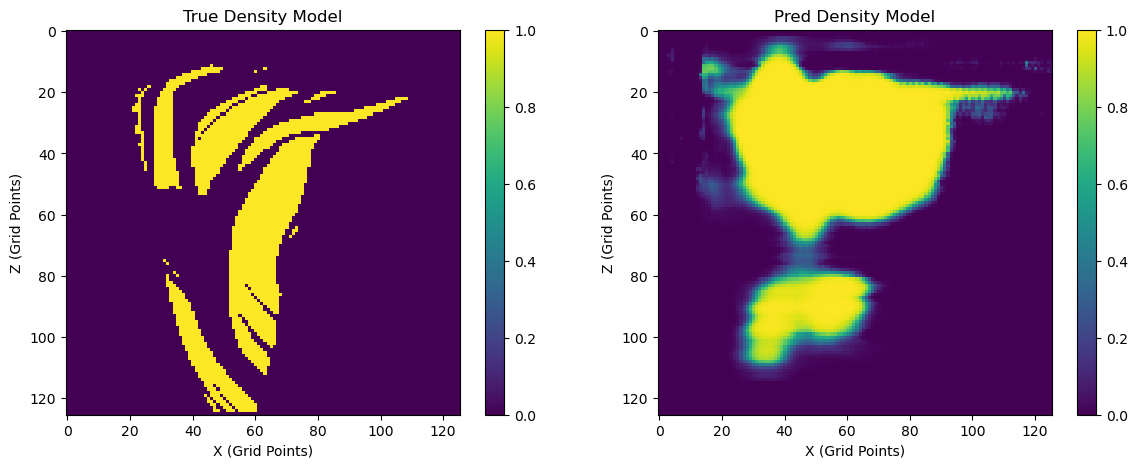

<Figure size 640x480 with 0 Axes>

In [3]:
label_path = r"E:\Research\benchmark\2D_benchmark\huoqiu_unet_test\density_huoqiu.npz"
label = np.load(label_path)['density']

model_type = "last_model"
pred_path = fr"E:\Research\benchmark\2D_benchmark\huoqiu_unet_test\v001\{model_type}\gravity_huoqiu_pred.npz"
pred = np.load(pred_path)['pred']

plot_test_result(label, pred[0,0])